In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("dirty_cafe_sales.csv")

df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [3]:
df.shape

(10000, 8)

In [4]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [5]:
df.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

In [7]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [10]:
df[["Quantity", "Price Per Unit", "Total Spent"]].head(20)

,Quantity,Price Per Unit,Total Spent
0,2,2.0,4.0
1,4,3.0,12.0
2,4,1.0,ERROR
3,2,5.0,10.0
4,2,2.0,4.0
5,5,4.0,20.0
6,3,3.0,9.0
7,4,4.0,16.0
8,5,3.0,15.0
9,5,4.0,20.0


In [11]:
# Convert numeric columns to numbers
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")

# Check the result
df[["Quantity", "Price Per Unit", "Total Spent"]].dtypes

Quantity          float64
Price Per Unit    float64
Total Spent       float64
dtype: object

In [12]:
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())
df["Price Per Unit"] = df["Price Per Unit"].fillna(df["Price Per Unit"].median())
df["Total Spent"] = df["Total Spent"].fillna(df["Total Spent"].median())

print(df[["Quantity", "Price Per Unit", "Total Spent"]].isnull().sum())

Quantity          0
Price Per Unit    0
Total Spent       0
dtype: int64


In [13]:
print("Item values:")
print(df["Item"].value_counts(dropna=False))

print("\nPayment Method values:")
print(df["Payment Method"].value_counts(dropna=False))

print("\nLocation values:")
print(df["Location"].value_counts(dropna=False))

Item values:
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
ERROR        292
Name: count, dtype: int64

Payment Method values:
Payment Method
NaN               2579
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
UNKNOWN            293
Name: count, dtype: int64

Location values:
Location
NaN         3265
Takeaway    3022
In-store    3017
ERROR        358
UNKNOWN      338
Name: count, dtype: int64


In [14]:
# Clean text columns
text_columns = ["Item", "Payment Method", "Location"]

for col in text_columns:
    df[col] = df[col].replace(["ERROR", "UNKNOWN"], np.nan)
    df[col] = df[col].fillna("Unknown")

# Check the result
print(df[text_columns].isnull().sum())

Item              0
Payment Method    0
Location          0
dtype: int64


In [15]:
# Convert Transaction Date to date format
df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"],
    errors="coerce"
)

# Check the result
print(df["Transaction Date"].dtype)
print("Missing dates:", df["Transaction Date"].isnull().sum())

datetime64[us]
Missing dates: 460


In [16]:
# Fill missing dates with the median date
median_date = df["Transaction Date"].dropna().sort_values().iloc[len(df["Transaction Date"].dropna()) // 2]

df["Transaction Date"] = df["Transaction Date"].fillna(median_date)

print("Missing dates after cleaning:", df["Transaction Date"].isnull().sum())

Missing dates after cleaning: 0


In [17]:
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(df.duplicated().sum())

print("\nFinal data types:")
print(df.dtypes)

Missing values after cleaning:
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

Duplicate rows after cleaning:
0

Final data types:
Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object


In [18]:
# Check for outliers using the IQR method

numeric_columns = ["Quantity", "Price Per Unit", "Total Spent"]

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    print(f"{col}: {outliers} outliers")

Quantity: 0 outliers
Price Per Unit: 0 outliers
Total Spent: 259 outliers


In [19]:
# Handle outliers using IQR capping

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outliers have been capped using the IQR method.")

Outliers have been capped using the IQR method.


In [20]:
print("FINAL DATASET SUMMARY")
print("---------------------")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

FINAL DATASET SUMMARY
---------------------
Rows: 10000
Columns: 8
Missing values: 0
Duplicate rows: 0


In [21]:
# Save the cleaned dataset
df.to_csv("cleaned_cafe_sales.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [22]:
before = {
    "Rows": 10000,
    "Columns": 8,
    "Missing Values": 7047,
    "Duplicate Rows": 0
}

after = {
    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum()
}

comparison = pd.DataFrame({
    "Before Cleaning": before,
    "After Cleaning": after
})

comparison

,Before Cleaning,After Cleaning
Rows,10000,10000
Columns,8,8
Missing Values,7047,0
Duplicate Rows,0,0


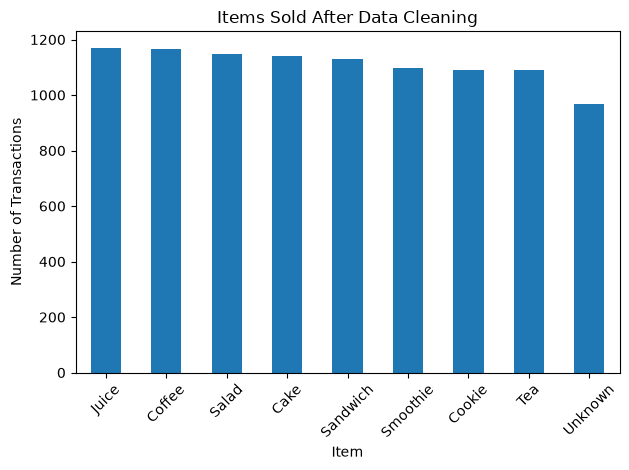

In [24]:
import matplotlib.pyplot as plt

df["Item"].value_counts().plot(kind="bar")

plt.title("Items Sold After Data Cleaning")
plt.xlabel("Item")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observations and Conclusion

### Observations
- The original dataset contained 10,000 rows and 8 columns.
- There were 7,047 missing values before cleaning.
- Missing values were successfully handled during the cleaning process.
- Numerical columns were converted into appropriate numeric data types.
- Transaction dates were converted into datetime format.
- Invalid and missing values were cleaned.
- There were no duplicate rows.
- Outliers in Total Spent were capped using the IQR method.
- After cleaning, the dataset contains 10,000 rows and 8 columns with zero missing values.
- Juice had the highest number of transactions in the cleaned dataset.

### Conclusion
The data cleaning process successfully transformed the raw cafe sales dataset into a clean and consistent dataset. The cleaned dataset is now suitable for further data analysis and visualization.